# Loading Dataset And Dependencies

In [115]:
import pandas as pd
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
scaler = StandardScaler()

In [116]:
# loading data
df_train = pd.read_csv("./data/train.csv")
df_test = pd.read_csv("./data/test.csv")
df_data = pd.concat([df_train, df_test], ignore_index=True)  # Concatenate train and test datasets

# Introduce New Features

In [117]:
# Encode sex
df_data['Sex_Code'] = df_data['Sex'].map({'female' : 1, 'male' : 0}).astype('int')


In [118]:
# Fill in missing fare values
df_data['Fare'] = df_data['Fare'].fillna(df_data['Fare'].median())

# Making Bins
df_data['FareBin_5'] = pd.qcut(df_data['Fare'], 5)

label = LabelEncoder()
df_data['FareBin_Code_5'] = label.fit_transform(df_data['FareBin_5'])

In [119]:
"""
Another way of binning, by clustering, incoporating the deck information
"""
def get_deck(cabin):
    if pd.isna(cabin):
        return 'Unknown'
    else:
        return cabin[0]

def deck_mapping(deck):
    deck_mapping_dict = {'Unknown': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 8}
    return deck_mapping_dict.get(deck, 0)

df_data['Deck'] = df_data['Cabin'].apply(get_deck)
df_data['Deck_encode'] = df_data['Deck'].apply(deck_mapping)

df_data['Fare'] = df_data['Fare'].fillna(df_data['Fare'].median())
fare_weight = 0.05
df_data['Fare_Scaled'] = df_data['Fare'] * fare_weight

features_for_clustering = df_data[['Fare_Scaled', 'Deck_encode']]

kmeans = KMeans(n_clusters=5, random_state=0)
df_data['FareDeck_5'] = kmeans.fit_predict(features_for_clustering)

label = LabelEncoder()
df_data['FareDeck_Code_5'] = label.fit_transform(df_data['FareDeck_5'])

c:\Users\jj186\anaconda3\envs\3.8\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [120]:
# # visualize the clustering
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='Fare', y='Deck_encode', hue='FareDeck_5', palette='viridis', data=df_data, s=100, alpha=0.6, edgecolor='w')
# plt.title('Fare and Cabin Clustering')
# plt.xlabel('Fare')
# plt.ylabel('Deck (Encoded)')
# plt.legend(title='Cluster')
# plt.show()

In [121]:
# Family_size
df_data['Family_size'] = df_data['SibSp'] + df_data['Parch'] + 1

# how about the fare values of deplicate tickets 
deplicate_ticket = []
for tk in df_data.Ticket.unique():
    tem = df_data.loc[df_data.Ticket == tk, 'Fare']
    if tem.count() > 1:
        deplicate_ticket.append(df_data.loc[df_data.Ticket == tk,['Name','Ticket','Fare','Cabin','Family_size','Survived']])
deplicate_ticket = pd.concat(deplicate_ticket)

In [122]:
# feature found out in [Blood is thicker than water & friendship forever](https://www.kaggle.com/shunjiangxu/blood-is-thicker-than-water-friendship-forever/code) by S.Xu. 
df_data['Connected_Survival'] = 0.5 # default 
for _, df_grp in df_data.groupby('Ticket'):
    if (len(df_grp) > 1):
        for ind, row in df_grp.iterrows():
            smax = df_grp.drop(ind)['Survived'].max()
            smin = df_grp.drop(ind)['Survived'].min()
            passID = row['PassengerId']
            if (smax == 1.0):
                df_data.loc[df_data['PassengerId'] == passID, 'Connected_Survival'] = 1
            elif (smin==0.0):
                df_data.loc[df_data['PassengerId'] == passID, 'Connected_Survival'] = 0

In [123]:
"""
one way of filling in missing age values
"""
# extracted title using name
df_data['Title'] = df_data.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
df_data['Title'] = df_data['Title'].replace(['Capt', 'Col', 'Countess', 'Don',
                                               'Dr', 'Dona', 'Jonkheer', 
                                                'Major','Rev','Sir'],'Rare') 
df_data['Title'] = df_data['Title'].replace(['Mlle', 'Ms','Mme'],'Miss')
df_data['Title'] = df_data['Title'].replace(['Lady'],'Mrs')
df_data['Title'] = df_data['Title'].map({"Mr":0, "Rare" : 1, "Master" : 2,"Miss" : 3, "Mrs" : 4 })
Ti_pred = df_data.groupby('Title')['Age'].median().values
df_data['Ti_Age'] = df_data['Age']
# Filling the missing age
for i in range(0,5):
    df_data.loc[(df_data.Age.isnull()) & (df_data.Title == i),'Ti_Age'] = Ti_pred[i]
df_data['Ti_Age'] = df_data['Ti_Age'].astype('int')

# extract minor
df_data['Age_copy'] = df_data['Age'].fillna(-1)
df_data['Minor'] = (df_data['Age_copy'] < 14.0) & (df_data['Age_copy']>= 0)
df_data['Minor'] = df_data['Minor'] * 1
# We could capture more 8 Master in Pclass = 3 by filling missing age 
df_data['Ti_Minor'] = ((df_data['Ti_Age']) < 14.0) * 1

In [124]:
"""
one way of filling in missing age values, by imputing
"""
from sklearn.ensemble import RandomForestRegressor

def random_forest_impute(df):
    known_age = df[df['New_Age'].notnull()]
    unknown_age = df[df['New_Age'].isnull()]
    
    X_train = known_age[['Pclass', 'Title']]
    y_train = known_age['New_Age']
    X_test = unknown_age[['Pclass', 'Title']]
    
    rfr = RandomForestRegressor(random_state=0, n_estimators=100)
    rfr.fit(X_train, y_train)
    
    predicted_ages = rfr.predict(X_test)
    df.loc[df['New_Age'].isnull(), 'New_Age'] = predicted_ages
    
    return df

impute_function = random_forest_impute
df_data['New_Age'] = df_data['Age']
df_data = impute_function(df_data)

df_data['Age_Group'] = pd.cut(df_data['New_Age'], bins=[0, 14, 60, 100], labels=['0', '1', '2']) # ['Child', 'Adult', 'Senior']

nan_count = df_data['Age_Group'].isna().sum()

# Training Models

## 1. Support Vector Machine

In [125]:
# Split back into train and test datasets
df_train = df_data[:len(df_train)]
df_test = df_data[len(df_train):]

minor = ['Sex_Code','Pclass','FareBin_Code_5','Connected_Survival','Ti_Minor']

X = df_train[minor]
y = df_train['Survived']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Initialize and train SVM model
svm_model = SVC(kernel='rbf', random_state=0)
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_train = svm_model.predict(X_train)
y_pred_val = svm_model.predict(X_val)

# Print training and validation accuracies
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train)}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val)}")

# # # --------------------------submit--------------------------------
# # X_Submit = df_test.drop(labels=['PassengerId'],axis=1)

# # minor_pred = svm_model.predict(X_Submit[minor])

# # submit = pd.DataFrame({"PassengerId": df_test['PassengerId'],
# #                       "Survived":minor_pred.astype(int)})
# # submit.to_csv("./submits/svm.csv",index=False)

Training Accuracy: 0.8414481897627965
Validation Accuracy: 0.8666666666666667


## 2. Grid search SVM

In [126]:
# from sklearn.svm import SVC
# from sklearn.model_selection import GridSearchCV

# # Split back into train and test datasets
# df_train = df_data[:len(df_train)]
# df_test = df_data[len(df_train):]

# minor = ['Sex_Code','Pclass','FareBin_Code_5','Connected_Survival','Ti_Minor']

# X = df_train[minor]
# y = df_train['Survived']

# # Train-test split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# # Define SVM model
# svm_model = SVC(random_state=0)

# # Define parameter grid for GridSearchCV
# param_grid = {
#     'kernel': ['linear', 'rbf', 'sigmoid'],
#     'C': [0.1, 1, 10, 100],
#     'gamma': ['scale', 0.1, 1]
# }

# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy')

# # Fit GridSearchCV on training data
# grid_search.fit(X_train, y_train)

# # Get best parameters and best score
# best_params = grid_search.best_params_
# best_score = grid_search.best_score_

# print(f"Best Parameters: {best_params}")
# print(f"Best Cross-validation Accuracy: {best_score}")

# # Use best model for prediction
# best_svm_model = grid_search.best_estimator_
# y_pred = best_svm_model.predict(X_val)

# # --------------------------submit--------------------------------
# X_Submit = df_test.drop(labels=['PassengerId'],axis=1)

# minor_pred = best_svm_model.predict(X_Submit[minor])

# submit = pd.DataFrame({"PassengerId": df_test['PassengerId'],
#                       "Survived":minor_pred.astype(int)})
# submit.to_csv("./submits/svm.csv",index=False)

## 2. Plot Learning Curve

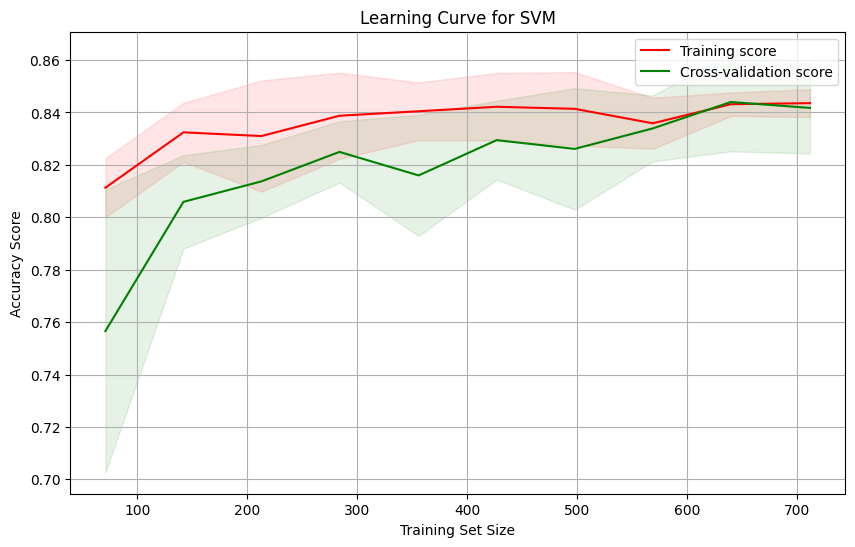

In [127]:
# Split back into train and test datasets (assuming df_data, df_train, and df_test are defined)
df_train = df_data[:len(df_train)]
df_test = df_data[len(df_train):]

minor = ['Sex_Code', 'Pclass', 'FareBin_Code_5', 'Connected_Survival', 'Ti_Minor']

X = df_train[minor]
y = df_train['Survived']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Initialize and train SVM model
svm_model = SVC(kernel='rbf', random_state=0)
svm_model.fit(X_train, y_train)

# Plot learning curve
train_sizes, train_scores, valid_scores = learning_curve(
    svm_model, X[minor], y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score', color='r')
plt.plot(train_sizes, valid_scores_mean, label='Cross-validation score', color='g')

plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std, valid_scores_mean + valid_scores_std, alpha=0.1, color='g')

plt.title('Learning Curve for SVM')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()